# **Model Recovery Tutorial**

In [2]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns

### **The idea of model recovery is to verify that the established models' behavior can be efficiently distinguishable from one another. Ideally, what this means is that if I simulate behavior from the Model Based Value learner and isolate the behavior I could "recover" the model it came from, which is the Model Based Value learner.**

### **The broader purpose is that if we can establish that the behavior of these predefined models are easily distinguishable from one another, we cam then fit the behavior from our neural network cortico-striatal circuit model and "recover" what predifined model is the best fit.**

### **The Bayesian Information Criterion (BIC) will be used to see which model is the best fit given behavioral data.**

$$
\text{BIC} = k \ln(n) - 2 \ln(\hat{L})
$$

- $n$ is the number of trials in dataset
- $k$ is the number of parameters in the model
- $\hat{L}$ is the likelihood of the observed choice sequence using the model 

### **Example of Model Recovery**

*Note that Model_Recovery.py generated each of the rows seen in the raw count matrix. I manually then created the following matrices you see.*

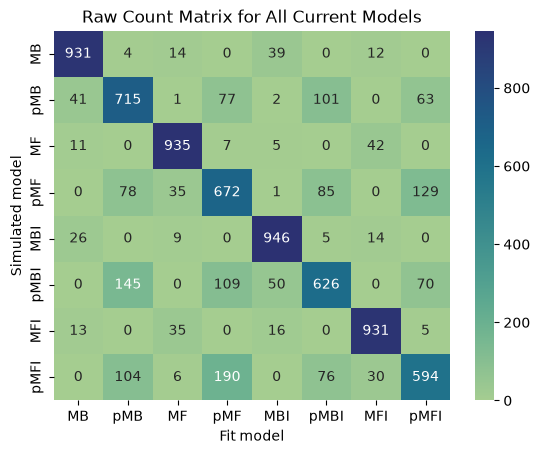

In [3]:
matrix = np.array([
    [931, 4, 14, 0, 39, 0, 12, 0],
    [41, 715, 1, 77, 2, 101, 0, 63],
    [11, 0, 935, 7, 5, 0, 42, 0],
    [0, 78, 35, 672, 1, 85, 0, 129],
    [26, 0, 9, 0, 946, 5, 14, 0],
    [0, 145, 0, 109, 50, 626, 0, 70],
    [13, 0, 35, 0, 16, 0, 931, 5],
    [0, 104, 6, 190, 0, 76, 30, 594]
    ])

collab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
rowlab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
ax = sns.heatmap(matrix, fmt = "d", annot=True, cmap='crest', yticklabels= collab, xticklabels= rowlab)
ax.set_title("Raw Count Matrix for All Current Models")
ax.set_ylabel("Simulated model")
ax.set_xlabel("Fit model")
plt.show()

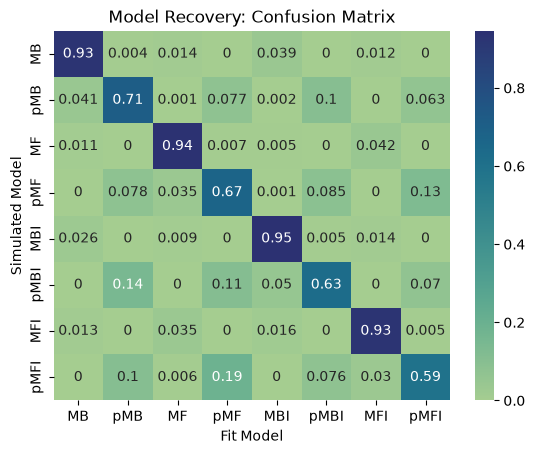

In [4]:
confusion = matrix/ matrix.sum(axis=1)
confusion
collab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
rowlab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]

ax = sns.heatmap(confusion, annot=True, cmap='crest', yticklabels= collab, xticklabels= rowlab)
ax.set_title("Model Recovery: Confusion Matrix")
ax.set_ylabel("Simulated Model")
ax.set_xlabel("Fit Model")
plt.show()

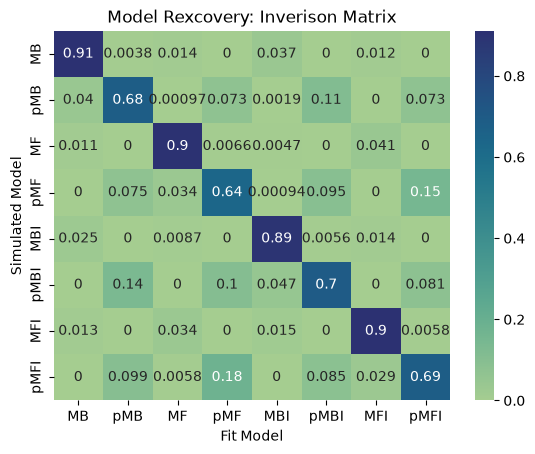

In [5]:
inversion = matrix / matrix.sum(axis=0)
collab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
rowlab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
ax = sns.heatmap(inversion, annot=True, cmap='crest', xticklabels= rowlab, yticklabels=collab)
ax.set_title("Model Rexcovery: Inverison Matrix")
ax.set_ylabel("Simulated Model")
ax.set_xlabel("Fit Model")
plt.show()

### **Example of Model Recovery of Neural Network Behavioral Data**

*Note that Model_Recovery.py generated the raw array but I then manually created the matrix below with seaborn.*

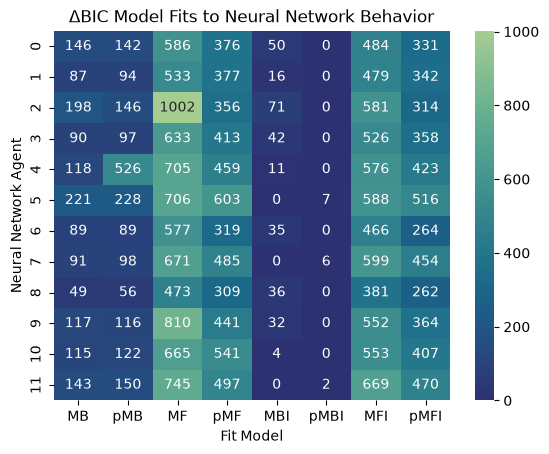

In [7]:
matrix = np.array([ 
    [146.42179785,  142.47234077,  585.61230633,  375.92303178,   49.59054789, 0,          483.61019227,  330.59043386],
    [87.15495261,   93.84621896,  533.38926751,  377.15683826,   15.89320264, 0,          479.02368751,  341.82051443],
    [ 197.75770906,  145.85305167, 1001.67355964,  356.26558909,   70.73750219, 0,          581.12021174,  313.92225226],
    [  90.333896,     96.51460808,  633.30011411,  412.86604515,   42.03417823, 0,          526.16737107,  358.20083319],
    [ 117.96021906,  526.2857747,   704.65847525,  458.93709584,   11.16853774, 0,          576.47814971,  422.55458681],
    [ 221.46139631, 228.36714957,  705.98081477,  603.39292215,    0, 6.90575328,  587.97709454, 516.19912111],
    [  89.28232156,   88.62201174,  577.08540232,  318.69940364,   34.78476322, 0,          465.77026936,  263.55077739],
    [  91.36237137,   98.26310203,  671.02876831,  484.56030294,    0, 5.69360296,  598.97835142,  454.33373332],
    [  49.39287036,   55.73633578,  473.0342756,  309.26138662,   35.74663388, 0,          381.47363304,  262.47108869],
    [ 117.49073049,  115.83568834,  809.81285547, 440.85950771,   31.92057371, 0,          552.29264053,  364.44773994],
    [ 115.05085466,  121.95460192,  664.79456422,  541.14563974,    3.67847439, 0,          552.88969595,  407.13665483],
    [ 143.44681004,  150.34945866,  744.55509826,  497.37774616,    0, 1.52579883,  669.36223636,  469.7460834 ]
])

collab = ['MB', 'pMB','MF', 'pMF', 'MBI','pMBI', "MFI", "pMFI"]
rowlab = ['0','1','2','3','4','5','6', '7','8','9','10','11']

ax = sns.heatmap(matrix, fmt = ".0f", annot=True, cmap='crest_r', yticklabels= rowlab, xticklabels= collab)
ax.set_title(r"$\Delta$BIC Model Fits to Neural Network Behavior")
ax.set_ylabel("Neural Network Agent")
ax.set_xlabel("Fit Model")
plt.show()